We will adapt the approach used [here](https://github.com/Armanfard-Lab/AADSCL#) to the teacher-student architecture of DINO.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATA_ROOT = Path('fan')

MACHINE = 'fan'
MACHINE_ID = 0

Using device: cuda


In [11]:
import os

class MIMII(Dataset):
    def __init__(self, data_dir, labels):
        self.labels = labels
        self.data_dir = data_dir

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        path = self.data_dir[idx]
        # Read with soundfile (this torchaudio build requires torchcodec for
        # torchaudio.load, which isn't installed). soundfile returns (T, C).
        x, sr = sf.read(path, dtype='float32', always_2d=True)
        if x.size == 0:
            raise ValueError(f"Empty audio file: {path}")
        x = torch.from_numpy(x).mean(dim=1)  # mix down to mono -> (T,)
        y = self.labels[idx]
        return x, y

def audiodir(machine, id=0, Data='normal'):
  '''
  Find the audio directory
  Inputs:
  machine: Name of the machine (valve/slider/fan/pump)
  id: ID of the machine (0,2,4,6)

  Outputs:
  dir: List of data addresses
  label: List of labels (0 -> normal, 1 -> abnormal)
  '''

  # Support both structures: machine/id_XX/normal and machine/normal
  id_dir = os.path.join(machine, 'id_' + str(format(id, '02d')))
  flat_dir = os.path.join(machine)

  if os.path.isdir(id_dir):
    normaldir = os.path.join(id_dir, 'normal')
    abnormaldir = os.path.join(id_dir, 'abnormal')
  else:
    normaldir = os.path.join(flat_dir, 'normal')
    abnormaldir = os.path.join(flat_dir, 'abnormal')

  if not os.path.isdir(normaldir):
    raise FileNotFoundError(f"Normal data directory not found: {normaldir}")
  if not os.path.isdir(abnormaldir):
    raise FileNotFoundError(f"Abnormal data directory not found: {abnormaldir}")

  dirs = []
  label = []
  if Data == 'normal':
    file_list = sorted(os.listdir(normaldir))
    for i in file_list:
      if i.endswith('.wav'):
        dir_address = os.path.join(normaldir, i)
        dirs.append(dir_address)
        label.append(0)
  else:
    file_list = sorted(os.listdir(abnormaldir))
    for i in file_list:
      if i.endswith('.wav'):
        dir_address = os.path.join(abnormaldir, i)
        dirs.append(dir_address)
        label.append(1)

  return dirs, label

def train_test(machine='Pump', id=0, train_size=0.75, num_workers=0):
  # num_workers=0 keeps data loading in the main process. In a notebook on
  # Python 3.14 (default 'forkserver' start method) using workers makes them
  # re-import the notebook-defined `MIMII` class, which fails with
  # "module '__main__' has no attribute 'MIMII'". Set >0 only if MIMII lives
  # in an importable .py module.
  dir_normal, label_normal = audiodir(machine, id)
  dir_abnormal, label_abnormal = audiodir(machine, id, Data='abnormal')

  dataset_normal = MIMII(dir_normal, label_normal)
  dataset_abnormal = MIMII(dir_abnormal, label_abnormal)

  n_train = int(len(dataset_normal) * train_size)
  n_test = len(dataset_normal) - n_train
  train_dataset, test_normal_dataset = torch.utils.data.random_split(
      dataset_normal, [n_train, n_test]
  )

  test_dataset = ConcatDataset([test_normal_dataset, dataset_abnormal])

  Train = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=num_workers, drop_last=True)
  Test = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=num_workers)

  print(f"Machine: {machine}, ID: {id}")
  print(f"  Normal samples: {len(dataset_normal)} (train: {n_train}, test: {n_test})")
  print(f"  Abnormal samples: {len(dataset_abnormal)}")
  print(f"  Total test: {len(test_dataset)}")

  return Train, Test

In [12]:
print("Preparing data...")
Train, Test = train_test(machine=MACHINE, id=MACHINE_ID)

Preparing data...
Machine: fan, ID: 0
  Normal samples: 1011 (train: 758, test: 253)
  Abnormal samples: 407
  Total test: 660


In [ ]:
def trainer(Train, f=None, g=None, CLS=None, NTXent=None, CELoss=None,
            num_epochs=400, verbosity=1, pretrain=False, save_path="state_dict_model.pt"):
  if f is None:
    f = resnet18().to(device)
  if g is None:
    g = Projection(hidden_dim=256).to(device)
  if CLS is None:
    CLS = LinCLS().to(device)
  if NTXent is None:
    NTXent = losses.NTXentLoss(temperature=0.07)
  if CELoss is None:
    CELoss = torch.nn.CrossEntropyLoss()

  if not pretrain:
    optimizer = torch.optim.Adam([
                    {'params': f.parameters()},
                    {'params': g.parameters()},
                    {'params': CLS.parameters(),}
                ], lr=1e-2)

    for epoch in range(num_epochs):
      f.train()
      g.train()
      CLS.train()
      epoch_loss = 0
      num_batch = 0
      for train_features, train_labels in Train:
        X, Y = apply_transform(train_features, train_labels)
        optimizer.zero_grad()
        X = X.to(device)
        Y = Y.to(device)
        Y_NTXent = torch.arange(X.shape[0])
        Y_NTXent[int(X.shape[0]/2):] = Y_NTXent[0:int(X.shape[0]/2)]
        h = f(X)
        z = g(h)
        cls_pred = CLS(h)
        loss = NTXent(z, Y_NTXent) + 0.1 * CELoss(cls_pred, Y.long())

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batch += 1
      if verbosity > 0:
        print("epoch : {}/{}, loss = {:.6f}".format(epoch + 1, num_epochs, epoch_loss / num_batch))

    # Save model after training
    torch.save(f.state_dict(), save_path)
    print(f"Model saved to {save_path}")
  else:
    PATH = save_path
    f.load_state_dict(torch.load(PATH, map_location=device, weights_only=True))
    print(f"Model loaded from {PATH}")

  return f, g, CLS


## DINO self-supervised adaptation

We convert the AADSCL supervised-contrastive setup into DINO self-distillation:

- **Student + Teacher** share the architecture (ResNet-18 backbone + `DINOHead`). The teacher is an EMA copy of the student and receives no gradients.
- **No labels and no negatives.** The loss is the cross-entropy between the teacher's (sharpened, centered) output distribution and the student's. Collapse is prevented by teacher centering + temperature sharpening + stop-gradient.
- **Multi-crop.** From each clip's log-mel spectrogram we take 2 *global* time-crops and several *local* time-crops. The teacher sees only the global crops; the student sees all of them.
- `apply_transform` is the per-crop augmentation (SpecAugment-style freq/time masking + noise). The classifier `CLS` is no longer part of training and is kept only as a downstream linear probe.

In [4]:
import os
import torchaudio
import torchvision
import torchaudio.transforms as AT
import torch.nn.functional as F
from torchvision.models import resnet18 as _resnet18

device = DEVICE  # cell 1 defines DEVICE; trainer code below uses lowercase `device`

# ----- audio feature config -----
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128
FIXED_FRAMES = 128  # all crops are resized to this width before the backbone

mel_extractor = AT.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)
amp_to_db = AT.AmplitudeToDB(stype='power', top_db=80).to(device)

# SpecAugment masks (operate on the (B, 1, mel, frame) tensor)
freq_mask = AT.FrequencyMasking(freq_mask_param=24)
time_mask = AT.TimeMasking(time_mask_param=24)


def make_resnet18():
    """ResNet-18 adapted to single-channel spectrograms; outputs 512-d features."""
    m = _resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Identity()
    return m

BACKBONE_DIM = 512


def to_logmel(waveform):
    """(B, T) raw audio -> per-sample-normalized log-mel (B, 1, N_MELS, frames)."""
    spec = mel_extractor(waveform)        # (B, N_MELS, frames)
    spec = amp_to_db(spec).unsqueeze(1)   # (B, 1, N_MELS, frames)
    mean = spec.mean(dim=(2, 3), keepdim=True)
    std = spec.std(dim=(2, 3), keepdim=True) + 1e-5
    return (spec - mean) / std


def apply_transform(spec, train=True):
    """Per-crop augmentation on a log-mel spectrogram (B, 1, mel, frame)."""
    if not train:
        return spec
    spec = freq_mask(spec)
    spec = time_mask(spec)
    if random.random() < 0.5:
        spec = spec + 0.1 * torch.randn_like(spec)
    return spec


def _rand_time_crop(spec, width):
    Tt = spec.shape[-1]
    if width >= Tt:
        return spec
    start = random.randint(0, Tt - width)
    return spec[..., start:start + width]


def multi_crop(waveform, n_global=2, n_local=6,
               global_frac=0.6, local_frac=0.25, train=True):
    """(B, T) raw audio -> list of augmented, equal-sized spectrogram crops.
    The first `n_global` entries are the global crops (fed to the teacher)."""
    spec = to_logmel(waveform.to(device))     # (B, 1, N_MELS, Tt)
    Tt = spec.shape[-1]
    g, l = max(1, int(Tt * global_frac)), max(1, int(Tt * local_frac))
    crops = [_rand_time_crop(spec, g) for _ in range(n_global)]
    crops += [_rand_time_crop(spec, l) for _ in range(n_local)]
    crops = [F.interpolate(c, size=(N_MELS, FIXED_FRAMES),
                           mode='bilinear', align_corners=False) for c in crops]
    return [apply_transform(c, train=train) for c in crops]

In [5]:
import copy


class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=1024, hidden_dim=512, bottleneck_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False  # freeze norm for stability

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)


class MultiCropWrapper(nn.Module):
    """Runs backbone+head over a list of crops, batching equal-shaped crops
    into a single forward pass (as in the original DINO)."""
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, crops):
        if not isinstance(crops, (list, tuple)):
            crops = [crops]
        idx_splits = [0]
        for i in range(1, len(crops)):
            if crops[i].shape[-1] != crops[i - 1].shape[-1]:
                idx_splits.append(i)
        idx_splits.append(len(crops))
        out = []
        for s, e in zip(idx_splits[:-1], idx_splits[1:]):
            out.append(self.backbone(torch.cat(crops[s:e])))
        return self.head(torch.cat(out))


class DINOLoss(nn.Module):
    def __init__(self, out_dim, teacher_temp=0.04, student_temp=0.1,
                 center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_out, teacher_out, n_student_crops, n_teacher_crops):
        student = (student_out / self.student_temp).chunk(n_student_crops)
        teacher = F.softmax((teacher_out - self.center) / self.teacher_temp, dim=-1)
        teacher = teacher.detach().chunk(n_teacher_crops)

        total, n_terms = 0.0, 0
        for iq, q in enumerate(teacher):           # teacher (global) crops
            for iv, v in enumerate(student):       # all student crops
                if iv == iq:
                    continue                       # skip identical crop pair
                total += torch.sum(-q * F.log_softmax(v, dim=-1), dim=-1).mean()
                n_terms += 1
        self.update_center(teacher_out)
        return total / n_terms

    @torch.no_grad()
    def update_center(self, teacher_out):
        batch_center = teacher_out.mean(dim=0, keepdim=True)
        self.center.mul_(self.center_momentum).add_(
            batch_center * (1 - self.center_momentum))


@torch.no_grad()
def ema_update(student, teacher, m):
    for ps, pt in zip(student.parameters(), teacher.parameters()):
        pt.data.mul_(m).add_(ps.detach().data, alpha=1 - m)

In [6]:
def dino_trainer(Train, num_epochs=400, n_global=2, n_local=6, out_dim=1024,
                 momentum_teacher=0.996, lr=5e-4, weight_decay=0.04,
                 verbosity=1, pretrain=False, save_path="dino_student.pt"):
    student = MultiCropWrapper(make_resnet18(), DINOHead(BACKBONE_DIM, out_dim)).to(device)
    teacher = MultiCropWrapper(make_resnet18(), DINOHead(BACKBONE_DIM, out_dim)).to(device)
    teacher.load_state_dict(student.state_dict())
    for p in teacher.parameters():
        p.requires_grad = False

    if pretrain:
        student.backbone.load_state_dict(
            torch.load(save_path, map_location=device, weights_only=True))
        print(f"Backbone loaded from {save_path}")
        return student, teacher

    dino_loss = DINOLoss(out_dim).to(device)
    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        student.train()
        epoch_loss, num_batch = 0, 0
        for x, _ in Train:                                  # labels ignored (self-supervised)
            crops = [c.to(device) for c in multi_crop(x, n_global, n_local, train=True)]
            teacher_out = teacher(crops[:n_global])         # global crops only
            student_out = student(crops)                    # all crops
            loss = dino_loss(student_out, teacher_out, n_global + n_local, n_global)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ema_update(student, teacher, momentum_teacher)  # EMA teacher update

            epoch_loss += loss.item()
            num_batch += 1
        if verbosity > 0:
            print("epoch : {}/{}, loss = {:.6f}".format(
                epoch + 1, num_epochs, epoch_loss / num_batch))

    torch.save(student.backbone.state_dict(), save_path)
    print(f"Backbone saved to {save_path}")
    return student, teacher


# student, teacher = dino_trainer(Train, num_epochs=100)

In [19]:
student, teacher = dino_trainer(Train, num_epochs=100)

/home/wikiwa/Documents/Erdos/DeepLearning_26_Summer/SLLsoundAnomaly/.venv/lib/python3.14/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


epoch : 1/100, loss = 5.456297
epoch : 2/100, loss = 5.546423
epoch : 3/100, loss = 6.187280
epoch : 4/100, loss = 6.588450
epoch : 5/100, loss = 6.654585
epoch : 6/100, loss = 6.543452
epoch : 7/100, loss = 6.387311
epoch : 8/100, loss = 6.265608
epoch : 9/100, loss = 6.139342
epoch : 10/100, loss = 6.021419
epoch : 11/100, loss = 5.863808
epoch : 12/100, loss = 5.770997
epoch : 13/100, loss = 5.582446
epoch : 14/100, loss = 5.406100
epoch : 15/100, loss = 5.334514
epoch : 16/100, loss = 5.111497
epoch : 17/100, loss = 4.983703
epoch : 18/100, loss = 4.803320
epoch : 19/100, loss = 4.670867
epoch : 20/100, loss = 4.559161
epoch : 21/100, loss = 4.416345
epoch : 22/100, loss = 4.264484
epoch : 23/100, loss = 4.200580
epoch : 24/100, loss = 3.991079
epoch : 25/100, loss = 3.921475
epoch : 26/100, loss = 3.815017
epoch : 27/100, loss = 3.711477
epoch : 28/100, loss = 3.599970
epoch : 29/100, loss = 3.486097
epoch : 30/100, loss = 3.391897
epoch : 31/100, loss = 3.385946
epoch : 32/100, l

## Evaluation: Mahalanobis anomaly detection

DINO is trained without labels, so we evaluate the learned representation directly. We freeze the student backbone, extract a deterministic **global-view** feature (full log-mel, no crops/augmentation) for every clip, and fit a Gaussian (mean + regularized covariance) to the *normal* training features. Each test clip is scored by its **Mahalanobis distance** from that normal distribution — higher distance = more anomalous. We then report ROC-AUC against the true normal/abnormal labels.

Test ROC-AUC: 0.5472


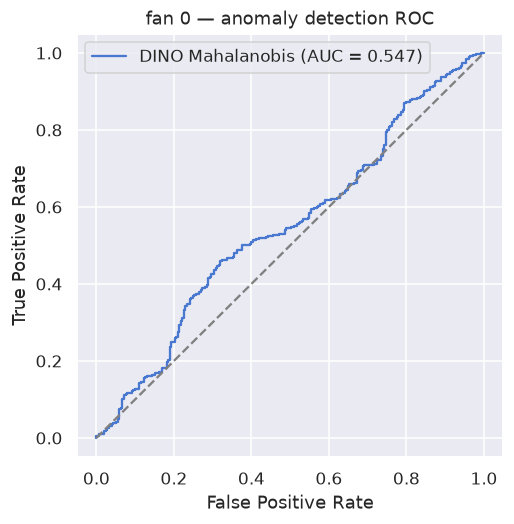

In [20]:
@torch.no_grad()
def extract_features(backbone, loader):
    """Deterministic global-view features (full spectrogram, no crops/aug)."""
    backbone.eval()
    feats, labels = [], []
    for x, y in loader:
        spec = to_logmel(x.to(device))
        spec = F.interpolate(spec, size=(N_MELS, FIXED_FRAMES),
                             mode='bilinear', align_corners=False)
        feats.append(backbone(spec).cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)


def fit_gaussian(train_feats, eps=1e-3):
    """Fit mean + (regularized) inverse covariance of the normal feature distribution."""
    mu = train_feats.mean(dim=0)
    centered = train_feats - mu
    cov = centered.t() @ centered / (train_feats.shape[0] - 1)
    cov += eps * torch.eye(cov.shape[0])          # shrinkage for invertibility
    cov_inv = torch.linalg.inv(cov)
    return mu, cov_inv


def mahalanobis_score(test_feats, mu, cov_inv):
    """Mahalanobis distance of each test feature from the normal distribution."""
    centered = test_feats - mu                      # (n_test, d)
    m = (centered @ cov_inv * centered).sum(dim=1)  # quadratic form, (n_test,)
    return torch.sqrt(m.clamp_min(0.0))             # higher = more anomalous


# Fit the normal (training) distribution, then score the test set
train_feats, _ = extract_features(student.backbone, Train)
test_feats, test_labels = extract_features(student.backbone, Test)

mu, cov_inv = fit_gaussian(train_feats)
scores = mahalanobis_score(test_feats, mu, cov_inv)
y_true, y_score = test_labels.numpy(), scores.numpy()
auc = roc_auc_score(y_true, y_score)
print(f"Test ROC-AUC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_true, y_score)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"DINO Mahalanobis (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{MACHINE} {MACHINE_ID} — anomaly detection ROC")
plt.legend()
plt.show()